In [ ]:
from qiskit.quantum_info import Statevector
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from fermion import *
from entropy import *

exact_model = Fermion_Model(tunneling=1.0, coulomb=0.5)
analog_model = Analog_Fermion(exact_model)

initial_state = Statevector.from_label('1100111100110000').data  # Example initial state
time=np.linspace(0,5,51)
exact_state=initial_state
analog_state=initial_state
time_step=0.1
error=[]
entropy=[]
for _ in tqdm(time):
    analog_state = analog_model.evolve_state(exact_state, time_step, analog_model.H)
    exact_state = exact_model.evolve_state(exact_state, time_step, exact_model.H)
    error.append(np.linalg.norm(exact_state - analog_state))
    # entropy.append(RDM_entropy(analog_state, 4,16)[-1])
    rho=partial_trace(Statevector(analog_state),[4,5,6,7,8,9,10,11,12,13,14,15])
    entropy.append(von_neumann_entropy(rho))

100%|██████████| 51/51 [00:27<00:00,  1.82it/s]


In [9]:
from math import sqrt
d=2**16
H_noise=get_sparse_operator(exact_model.H-analog_model.H).toarray()
fro_norm=np.linalg.norm(H_noise,'fro')/sqrt(d)*time_step

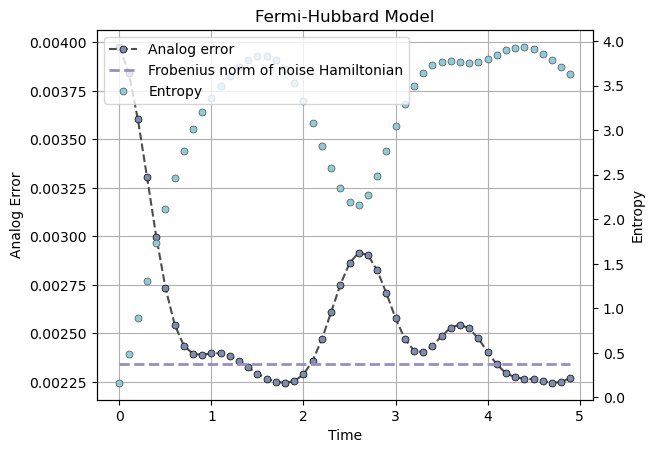

In [ ]:
p11=plt.plot(time[:-1], error[:-1],color='0.3', marker='o', markersize=5, mfc="#7E8CAD", mec='k', linestyle='dashed', markeredgewidth=0.5,label='Analog error')
p12=plt.plot(time[:-1], [fro_norm]*len(time[:-1]),'--',color="#998DC2",linewidth=2,label='Frobenius norm of noise Hamiltonian')
plt.grid()
plt.xlabel('Time')
plt.ylabel('Analog Error')
# plt.ylim( top=0.3)
ax1=plt.gca()
ax2 = ax1.twinx()
p2=ax2.plot(time[:-1], entropy[:-1],color='0.3', marker='o', markersize=5, mfc="#8ECBDB", linestyle='', markeredgewidth=0.5,label='Entropy')
ax2.set_ylabel('Entropy')
lns=p11+p12+p2
labs=[l.get_label() for l in lns]
plt.legend(lns, labs, loc=2)

plt.title('Fermi-Hubbard Model')
plt.savefig('Figures/fermion_error_new4.pdf', bbox_inches='tight',dpi=600)
plt.show()
